# Main V6 — Frequency-Band PDC Pipeline

## Motivation

V3–V5b use **broadband GC** (A_total = Σ|A_k| over all lags), which collapses all frequency-domain information into a single directed graph. The seminal work of Hejazi & Motie Nasrabadi (2019, *Epilepsy & Behavior*) found that **alpha-band (8–13 Hz) directed connectivity** is the most discriminative for preictal detection, substantially outperforming broadband measures. DTF and PDC in specific bands are also used by Schelter et al. (2006, *Clinical Neurophysiology*).

V6 tests this directly:

1. **Refit VAR(20)** on each window, keeping the full coefficient matrix **B** (18 × 360) instead of discarding it. VAR(5) captures only ~20ms — shorter than one alpha cycle (100ms). VAR(20) = 78ms gives enough lags for meaningful spectral decomposition. Hejazi & Motie Nasrabadi (2019) used p=10; p=20 is more conservative and used here.
2. **Compute PDC** (Partial Directed Coherence, Baccalá & Sameshima 2001) at every frequency, then **band-average** over delta / theta / alpha / beta.
3. **Extract 67 graph descriptors** (same as V4) from each band's 18×18 PDC matrix → 268 features total.
4. **Run the same LOPO ML pipeline** as V4 (LR/RF/XGB/SVM with inner GroupKFold).
5. Test each band separately *and* all-band combined to isolate which band drives performance.

## Why PDC_ORDER ≠ GC_ORDER

| Use | Order | Rationale |
|-----|-------|-----------|
| Broadband GC (V3–V5b) | p=5 | AIC/BIC optimal for A_total = Σ\|A_k\| (time-domain) |
| Frequency-band PDC (V6) | p=20 | Needs ≥1 oscillatory cycle per band; p=5 at 256Hz = 20ms — blind to alpha (100ms period) |

## PDC formula (Baccalá & Sameshima 2001)

For VAR(p) model X(t) = Σ A_k X(t−k) + ε, define the spectral matrix:

    H(f) = I − Σ_{k=1}^{p} A_k · exp(−j·2π·f·k / fs)

PDC from channel j → i at frequency f:

    PDC_{ij}(f) = H_{ij}(f) / sqrt( Σ_k |H_{kj}(f)|² )

Band PDC matrix: average |PDC(f)|² over frequency bins within the band.

## Frequency bands
| Band  | Hz    |
|-------|-------|
| Delta | 0.5–4 |
| Theta | 4–8   |
| Alpha | 8–13  |
| Beta  | 13–30 |

## 0 · Imports & config

In [1]:
# --- portable repo bootstrap (added for public release; locates the repo root) ---
import sys as _sys, pathlib as _pl
REPO = _pl.Path.cwd()
while not (REPO / 'src' / 'config.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
_sys.path.insert(0, str(REPO / 'src'))
from pathlib import Path
CODE_DIR = str(REPO); CODE = REPO; CODEV2 = REPO; PROJECT_DIR = REPO
# --------------------------------------------------------------------------------

# Cell 0 — Imports
import os, sys, json, warnings, time
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# [path set by bootstrap] CODE_DIR = r"<repo>/Code"
sys.path.insert(0, CODE_DIR)

from config import (
    DATA_ROOT, CANONICAL_CHANNELS, N_CHANNELS, FS,
    WINDOW_SEC, STEP_SEC, GC_ORDER,
    EXCLUDED_PATIENTS, GC_MATRICES_DIR_V3, RESULTS_DIR,
    INTERICTAL_MULTIPLIER, MAX_INTERICTAL_ABS, RANDOM_SEED,
)
from summary_parser import parse_summary, parse_all_summaries
from data_loader import load_edf
from preprocessing import preprocess_file

from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.svm              import SVC
from sklearn.preprocessing    import StandardScaler
from sklearn.pipeline         import Pipeline
from sklearn.model_selection  import GroupKFold, GridSearchCV
from sklearn.metrics          import (roc_auc_score, average_precision_score,
                                       roc_curve, precision_recall_curve)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    HAS_XGB = False

np.random.seed(RANDOM_SEED)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── V6-specific constants ──────────────────────────────────────────────────
# PDC_ORDER is separate from GC_ORDER (=5).
# VAR(5) at 256 Hz = 19.5ms — too short to resolve alpha (100ms cycle).
# VAR(20) = 78ms captures enough oscillatory structure for delta–beta PDC.
# Hejazi & Motie Nasrabadi (2019) used p=10; we use p=20 for more fidelity.
PDC_ORDER = 20

PDC_CACHE_DIR = os.path.join(CODE_DIR, 'cache_pdc_var20')
os.makedirs(PDC_CACHE_DIR, exist_ok=True)

# Frequency bands (name, low_hz, high_hz)
BANDS = [
    ('delta', 0.5,  4.0),
    ('theta', 4.0,  8.0),
    ('alpha', 8.0, 13.0),
    ('beta', 13.0, 30.0),
]
BAND_NAMES = [b[0] for b in BANDS]

print(f'Data root    : {DATA_ROOT}')
print(f'PDC cache    : {PDC_CACHE_DIR}')
print(f'FS={FS} Hz   GC_ORDER={GC_ORDER} (broadband)   PDC_ORDER={PDC_ORDER} (freq-domain)')
print(f'Bands        : {BAND_NAMES}')
print(f'B matrix dim : {N_CHANNELS} × {PDC_ORDER * N_CHANNELS}  (18 channels × {PDC_ORDER} lags)')
print(f'XGBoost      : {"available" if HAS_XGB else "unavailable"}')
print('V6 PDC notebook ready.')

Data root    : /Users/goncalopacheco/Documents/Master's/2º Year/Thesis/Code Final/data/physionet
PDC cache    : /Users/goncalopacheco/Documents/Master's/2º Year/Thesis/Code Final/cache_pdc_var20
FS=256 Hz   GC_ORDER=5 (broadband)   PDC_ORDER=20 (freq-domain)
Bands        : ['delta', 'theta', 'alpha', 'beta']
B matrix dim : 18 × 360  (18 channels × 20 lags)
XGBoost      : available
V6 PDC notebook ready.


## 1 · PDC core functions

In [2]:
# Cell 1 — PDC computation

def estimate_var_matrix(
    window: np.ndarray,
    p: int = PDC_ORDER,
    eps: float = 1e-10,
):
    """
    Fit VAR(p) via OLS and return the full coefficient matrix B.

    Model: X(t) = A_1 X(t-1) + ... + A_p X(t-p) + noise

    Returns
    -------
    B     : np.ndarray  shape (n_ch, p * n_ch)
            B[:, k*n_ch:(k+1)*n_ch] = A_{k+1}  (lag k+1, k=0..p-1)
    valid : bool
    """
    n_ch, T = window.shape
    X = window - window.mean(axis=1, keepdims=True)
    T_eff = T - p
    # Need more observations than parameters for OLS to be identified
    if T_eff < n_ch * p + 1:
        return np.zeros((n_ch, p * n_ch), dtype=np.float64), False

    Y = X[:, p:]                                                      # (n_ch, T_eff)
    Z = np.vstack([X[:, p - lag : p - lag + T_eff]
                   for lag in range(1, p + 1)])                       # (p*n_ch, T_eff)

    # eps*I regularisation ensures ZZT is always positive definite → always invertible.
    # No rank check needed: with T_eff=5100 >> p*n_ch=360 and real EEG,
    # ZZT is well-conditioned before regularisation.
    ZZT = (Z @ Z.T) / T_eff + eps * np.eye(p * n_ch)

    YZT = (Y @ Z.T) / T_eff
    B   = YZT @ np.linalg.inv(ZZT)                                    # (n_ch, p*n_ch)
    return B.astype(np.float64), True


def compute_pdc_bands(
    B: np.ndarray,
    bands: list = BANDS,
    fs: int = FS,
    p: int = PDC_ORDER,
    n_freq_per_hz: float = 4.0,
) -> dict:
    """
    Compute band-averaged PDC matrices from a VAR(p) coefficient matrix B.

    PDC formula (Baccalá & Sameshima 2001):
      H(f) = I - sum_{k=1}^{p} A_k * exp(-j*2*pi*f*k/fs)
      PDC_{ij}(f) = |H_{ij}(f)| / sqrt(sum_rows |H_{rj}(f)|^2)
      BandPDC_{ij} = mean_f( PDC_{ij}(f)^2 )  over frequencies in band

    Column sums: by construction sum_i BandPDC[i,j] = 1 for each j.

    Parameters
    ----------
    B              : (n_ch, p*n_ch)  VAR coefficient matrix
    bands          : list of (name, low_hz, high_hz)
    fs             : sampling frequency
    p              : VAR order (must match B's second dimension / n_ch)
    n_freq_per_hz  : frequency resolution (bins per Hz); 4 gives delta=14, alpha=20, beta=68 bins

    Returns
    -------
    band_pdc : dict  {band_name: np.ndarray (n_ch, n_ch)}
               BandPDC[i, j] = mean squared PDC from j -> i
    """
    n_ch = B.shape[0]
    I = np.eye(n_ch, dtype=complex)

    # Extract lag matrices: A_k = B[:, (k-1)*n_ch : k*n_ch]
    A_lags = [B[:, k * n_ch : (k + 1) * n_ch] for k in range(p)]    # list of p (n_ch, n_ch)

    band_pdc = {}
    for band_name, f_low, f_high in bands:
        n_bins = max(4, int((f_high - f_low) * n_freq_per_hz))
        freqs  = np.linspace(f_low, f_high, n_bins, endpoint=False)

        # Accumulate |PDC|^2 over frequencies
        pdc_sum = np.zeros((n_ch, n_ch), dtype=np.float64)

        for f in freqs:
            # H(f) = I - sum_{k=1}^{p} A_k * exp(-j*2*pi*f*k/fs)
            H = I.copy()
            for k, Ak in enumerate(A_lags):
                H -= Ak * np.exp(-1j * 2 * np.pi * f * (k + 1) / fs)

            # PDC_{ij}(f) = |H_{ij}(f)| / sqrt(sum_rows |H_{rj}(f)|^2)
            col_norms = np.sqrt((np.abs(H) ** 2).sum(axis=0))         # (n_ch,)
            col_norms = np.where(col_norms < 1e-15, 1e-15, col_norms)
            PDC = np.abs(H) / col_norms[np.newaxis, :]                # (n_ch, n_ch)

            pdc_sum += PDC ** 2

        band_pdc[band_name] = (pdc_sum / n_bins).astype(np.float32)

    return band_pdc


print('PDC functions defined.')

# Sanity check: B should be (18, 360) with p=20
_dummy = np.random.randn(N_CHANNELS, 20 * FS).astype(np.float32)
_B, _ok = estimate_var_matrix(_dummy, p=PDC_ORDER)
_bpdc   = compute_pdc_bands(_B, p=PDC_ORDER)
print(f'Sanity check: B shape={_B.shape}  valid={_ok}  (expect (18, {PDC_ORDER*18}))')
for bname, mat in _bpdc.items():
    col_sums = mat.sum(axis=0)   # each column should sum to ~1
    print(f'  {bname}: mean={mat.mean():.4f}  col_sum_min={col_sums.min():.3f}  col_sum_max={col_sums.max():.3f}')

PDC functions defined.
Sanity check: B shape=(18, 360)  valid=True  (expect (18, 360))
  delta: mean=0.0556  col_sum_min=1.000  col_sum_max=1.000
  theta: mean=0.0556  col_sum_min=1.000  col_sum_max=1.000
  alpha: mean=0.0556  col_sum_min=1.000  col_sum_max=1.000
  beta: mean=0.0556  col_sum_min=1.000  col_sum_max=1.000


## 2 · Feature extraction from PDC matrices

Same 67-feature descriptor as V4 (in-degree / out-degree / net-flow / scalars / SVD), applied to each of the 4 band PDC matrices independently. Total: 4 × 67 = 268 features.

In [3]:
# Cell 2 — Feature extraction (identical logic to V4, applied per band)

def extract_graph_features(A: np.ndarray) -> np.ndarray:
    """
    Extract 67 patient-invariant graph descriptors from a single 18x18
    directed connectivity matrix (PDC or GC).

    Applies Frobenius normalization first so absolute magnitudes don't
    encode patient-specific amplitude differences.
    """
    # Frobenius normalization — makes scale-invariant
    frob = np.linalg.norm(A, 'fro')
    if frob > 1e-10:
        A = A / frob

    n    = A.shape[0]
    off  = ~np.eye(n, dtype=bool)
    a_off = A[off]

    # Group A: channel-level (54)
    in_deg   = A.sum(axis=1) - np.diag(A)       # row sum excl diagonal
    out_deg  = A.sum(axis=0) - np.diag(A)       # col sum excl diagonal
    net_flow = out_deg - in_deg

    # Group B: network scalars (8)
    mean_off = a_off.mean()
    std_off  = a_off.std()
    max_off  = a_off.max()
    min_off  = a_off.min()

    asym     = np.abs(A - A.T)
    asym_off = asym[np.triu_indices(n, k=1)]
    mean_asym = asym_off.mean()
    std_asym  = asym_off.std()

    thr      = 0.5 * max(float(max_off), 1e-12)
    density  = float((a_off > thr).mean())
    eigvals  = np.linalg.eigvals(A)
    spec_rad = float(np.max(np.abs(eigvals)))

    # Group C: top-5 singular values (5)
    sv = np.linalg.svd(A, compute_uv=False)
    sv5 = sv[:5] if len(sv) >= 5 else np.pad(sv, (0, 5 - len(sv)))

    return np.concatenate([
        in_deg, out_deg, net_flow,
        [mean_off, std_off, max_off, min_off,
         mean_asym, std_asym, density, spec_rad],
        sv5,
    ]).astype(np.float32)


def feature_names_for_band(band: str) -> list:
    names = []
    for prefix in ['in_deg', 'out_deg', 'net_flow']:
        names += [f'{band}_{prefix}_{c}' for c in CANONICAL_CHANNELS]
    names += [f'{band}_{s}' for s in
              ['mean_off', 'std_off', 'max_off', 'min_off',
               'mean_asym', 'std_asym', 'density', 'spec_radius']]
    names += [f'{band}_sv_{k}' for k in range(1, 6)]
    return names


ALL_FEATURE_NAMES = []
for bname in BAND_NAMES:
    ALL_FEATURE_NAMES += feature_names_for_band(bname)

FEATS_PER_BAND = 67
print(f'Features per band : {FEATS_PER_BAND}')
print(f'Total (all bands) : {len(ALL_FEATURE_NAMES)}')
print(f'Band feature slices:')
for i, b in enumerate(BAND_NAMES):
    lo, hi = i * FEATS_PER_BAND, (i + 1) * FEATS_PER_BAND
    print(f'  {b}: [{lo}:{hi}]')

Features per band : 67
Total (all bands) : 268
Band feature slices:
  delta: [0:67]
  theta: [67:134]
  alpha: [134:201]
  beta: [201:268]


## 3 · Load data and compute / cache PDC features

The V3 cache stores A_total (18×18) but **not** the full B coefficient matrix, so we re-read EDF files from disk. Features are cached per-patient to `cache_pdc_var20/<pid>/`.

**Runtime estimate**: VAR(20) is ~4× slower than VAR(5) per window. Expect **20–40 min total** on first run (cache-once architecture — subsequent runs load in <30s).

In [4]:
# Cell 3 — Parse summaries
all_seizures = parse_all_summaries(DATA_ROOT)

patients_all = sorted([
    p for p in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, p))
    and p.startswith('chb')
    and p not in EXCLUDED_PATIENTS
])

print(f'Patients to process: {len(patients_all)}')
print(f'  {patients_all}')

[INFO] chb01: 7 seizure-containing files, 7 total seizures
[INFO] chb02: 3 seizure-containing files, 3 total seizures
[INFO] chb03: 7 seizure-containing files, 7 total seizures
[INFO] chb04: 3 seizure-containing files, 4 total seizures
[INFO] chb05: 5 seizure-containing files, 5 total seizures
[INFO] chb06: 7 seizure-containing files, 10 total seizures
[INFO] chb07: 3 seizure-containing files, 3 total seizures
[INFO] chb08: 5 seizure-containing files, 5 total seizures
[INFO] chb09: 3 seizure-containing files, 4 total seizures
[INFO] chb10: 7 seizure-containing files, 7 total seizures
[INFO] chb11: 3 seizure-containing files, 3 total seizures
[INFO] chb12: 13 seizure-containing files, 40 total seizures
[INFO] chb13: 8 seizure-containing files, 12 total seizures
[INFO] chb14: 7 seizure-containing files, 8 total seizures
[INFO] chb15: 14 seizure-containing files, 20 total seizures
[INFO] chb16: 6 seizure-containing files, 10 total seizures
[INFO] chb17: 3 seizure-containing files, 3 total

In [5]:
# Cell 4 — Compute/load PDC features per patient
#
# Cache layout:
#   cache_pdc_var20/<pid>/features.npy   shape (N_windows, 268)
#   cache_pdc_var20/<pid>/labels.npy     shape (N_windows,)
#
# NOTE: pdc_features_v6/ (without _p20) was computed with the wrong VAR order
# (p=5) and must NOT be used. This cell uses cache_pdc_var20/ (p=20).

def _patient_cache_paths(pid):
    pdir = Path(PDC_CACHE_DIR) / pid
    return pdir / 'features.npy', pdir / 'labels.npy'


def load_pdc_features_patient(pid, seizure_map, force_recompute=False):
    """
    Load (or compute and cache) PDC features for one patient.

    Returns
    -------
    X : (N, 268)  float32
    y : (N,)      int8   {0=interictal, 1=preictal}
    """
    feat_path, lab_path = _patient_cache_paths(pid)

    if not force_recompute and feat_path.exists() and lab_path.exists():
        X = np.load(str(feat_path))
        y = np.load(str(lab_path))
        print(f'  [PDC] Cache hit: {pid}  shape={X.shape}')
        return X, y

    feat_path.parent.mkdir(parents=True, exist_ok=True)
    pdir = Path(DATA_ROOT) / pid

    all_feats = []   # list of (N_win, 268) arrays
    all_labels = []  # list of (N_win,) arrays

    for edf_fname, seizures in sorted(seizure_map.items()):
        edf_path = pdir / edf_fname
        if not edf_path.exists():
            continue
        try:
            raw_data, fs = load_edf(str(edf_path))
        except Exception as e:
            print(f'  [PDC] Load error {edf_fname}: {e}')
            continue

        windows, labels, _ = preprocess_file(raw_data, seizures, fs)
        if len(windows) == 0:
            continue

        # Compute VAR(PDC_ORDER) + PDC per window
        file_feats = []
        n_invalid  = 0
        for win in windows:
            B, ok = estimate_var_matrix(win, p=PDC_ORDER)
            if not ok:
                n_invalid += 1
                file_feats.append(np.zeros(len(BAND_NAMES) * FEATS_PER_BAND, dtype=np.float32))
                continue

            band_pdcs = compute_pdc_bands(B, p=PDC_ORDER)
            all_band_feats = np.concatenate([
                extract_graph_features(band_pdcs[bname])
                for bname in BAND_NAMES
            ])  # 268-dim
            file_feats.append(all_band_feats)

        file_feats = np.stack(file_feats, axis=0)  # (N_win, 268)

        # Drop invalid windows (all-zero feature rows where VAR failed)
        valid_mask = ~np.all(file_feats == 0, axis=1)
        file_feats = file_feats[valid_mask]
        labels     = labels[valid_mask]

        if n_invalid > 0:
            print(f'    {edf_fname}: {n_invalid} rank-deficient windows dropped')

        all_feats.append(file_feats)
        all_labels.append(labels)

    if not all_feats:
        return None, None

    X = np.concatenate(all_feats,  axis=0).astype(np.float32)
    y = np.concatenate(all_labels, axis=0).astype(np.int8)

    np.save(str(feat_path), X)
    np.save(str(lab_path),  y)
    print(f'  [PDC] Computed+cached (p={PDC_ORDER}): {pid}  shape={X.shape}')
    return X, y


# ── Run for all patients ───────────────────────────────────────────────────
pdc_raw = {}   # pid -> (X_all, y_all)   — before interictal cap

t0 = time.time()
for pid in patients_all:
    if pid not in all_seizures:
        continue
    X, y = load_pdc_features_patient(pid, all_seizures[pid])
    if X is None or (y == 1).sum() == 0:
        print(f'  [PDC] Skipping {pid}: no preictal windows')
        continue
    pdc_raw[pid] = (X, y)

elapsed = time.time() - t0
print(f'\nDone in {elapsed/60:.1f} min')
print(f'Patients with PDC features: {sorted(pdc_raw.keys())}')

    [LABEL] Seizure at 1467s: preictal window out of bounds (would start at -333s) — skipping preictal label.
    [LABEL] Seizure at 1732s: preictal window out of bounds (would start at -68s) — skipping preictal label.
    [LABEL] Seizure at 1015s: preictal window out of bounds (would start at -785s) — skipping preictal label.
    [LABEL] Seizure at 1720s: preictal window out of bounds (would start at -80s) — skipping preictal label.
    [LABEL] Seizure at 327s: preictal window out of bounds (would start at -1473s) — skipping preictal label.
  [PDC] Computed+cached (p=20): chb01  shape=(1333, 268)
    [LABEL] Seizure at 130s: preictal window out of bounds (would start at -1670s) — skipping preictal label.
  [PDC] Computed+cached (p=20): chb02  shape=(635, 268)
    [LABEL] Seizure at 362s: preictal window out of bounds (would start at -1438s) — skipping preictal label.
    [LABEL] Seizure at 731s: preictal window out of bounds (would start at -1069s) — skipping preictal label.
    [LABE

In [6]:
# Cell 5 — Apply interictal cap (same as V3/V4)

pdc_data = {}   # pid -> (X_capped, y)

for pid, (X, y) in pdc_raw.items():
    n_pre = int((y == 1).sum())
    n_int = int((y == 0).sum())
    cap   = min(n_int, INTERICTAL_MULTIPLIER * n_pre, MAX_INTERICTAL_ABS)

    if n_int > cap:
        rng     = np.random.default_rng(RANDOM_SEED + hash(pid) % 10_000)
        int_idx  = np.where(y == 0)[0]
        keep_int = rng.choice(int_idx, size=cap, replace=False)
        pre_idx  = np.where(y == 1)[0]
        keep     = np.sort(np.concatenate([pre_idx, keep_int]))
        X, y = X[keep], y[keep]

    pdc_data[pid] = (X, y)
    print(f'  {pid}: pre={int((y==1).sum())}  int={int((y==0).sum())}  '
          f'ratio=1:{int((y==0).sum())//max(int((y==1).sum()),1)}')

patient_ids = sorted(pdc_data.keys())
print(f'\n{len(patient_ids)} patients, feature shape: {pdc_data[patient_ids[0]][0].shape}')
print(f'Total preictal   : {sum(int((y==1).sum()) for _,(_, y) in pdc_data.items()):,}')
print(f'Total interictal : {sum(int((y==0).sum()) for _,(_, y) in pdc_data.items()):,}')

  chb01: pre=296  int=1037  ratio=1:3
  chb02: pre=296  int=339  ratio=1:1
  chb03: pre=444  int=899  ratio=1:2
  chb04: pre=296  int=1480  ratio=1:5
  chb05: pre=444  int=582  ratio=1:1
  chb06: pre=1037  int=5000  ratio=1:4
  chb07: pre=445  int=2225  ratio=1:5
  chb08: pre=741  int=535  ratio=1:0
  chb09: pre=592  int=2231  ratio=1:3
  chb10: pre=888  int=3062  ratio=1:3
  chb13: pre=444  int=947  ratio=1:2
  chb14: pre=774  int=687  ratio=1:0
  chb15: pre=320  int=1600  ratio=1:5
  chb16: pre=347  int=493  ratio=1:1
  chb17: pre=444  int=384  ratio=1:0
  chb18: pre=592  int=699  ratio=1:1
  chb19: pre=296  int=475  ratio=1:1
  chb20: pre=369  int=536  ratio=1:1
  chb22: pre=296  int=513  ratio=1:1
  chb23: pre=608  int=1382  ratio=1:2
  chb24: pre=939  int=1684  ratio=1:1

21 patients, feature shape: (1333, 268)
Total preictal   : 10,908
Total interictal : 26,790


## 4 · LOPO ML pipeline

Same as V4 — LR, RF, XGB, SVM with inner GroupKFold and AUC-PR scoring. Tests three feature sets:

1. **All-band combined** (268 features)
2. **Alpha only** (67 features) — Hejazi & Motie Nasrabadi (2019) hypothesis
3. **Per-band loop** (delta / theta / alpha / beta separately)

In [7]:
# Cell 6 — LOPO machinery (identical logic to V4)

from seizure_metrics import generate_alarms, false_alarms_per_hour
from config import ALARM_K, ALARM_M, ALARM_REFRACTORY, STEP_SEC

def evaluate_fold(probs, y_test, n_interictal_hours):
    if len(np.unique(y_test)) < 2:
        return None
    auc    = roc_auc_score(y_test, probs)
    auc_pr = average_precision_score(y_test, probs)
    fpr, tpr, thr = roc_curve(y_test, probs)
    j_idx  = np.argmax(tpr - fpr)
    thresh = float(thr[j_idx])
    pred   = (probs >= thresh).astype(int)
    tp = int(((pred == 1) & (y_test == 1)).sum())
    fp = int(((pred == 1) & (y_test == 0)).sum())
    tn = int(((pred == 0) & (y_test == 0)).sum())
    fn = int(((pred == 0) & (y_test == 1)).sum())
    sens   = tp / max(tp + fn, 1)
    spec   = tn / max(tn + fp, 1)
    prec   = tp / max(tp + fp, 1)
    f1     = 2 * prec * sens / max(prec + sens, 1e-9)
    bal    = 0.5 * (sens + spec)
    fpr_h  = false_alarms_per_hour(generate_alarms(pred.astype(float), 0.5, ALARM_K, ALARM_M, ALARM_REFRACTORY), y_test, STEP_SEC)
    return dict(auc=auc, auc_pr=auc_pr, sensitivity=sens, specificity=spec,
                precision=prec, f1=f1, balanced_accuracy=bal,
                fpr_per_hour=fpr_h)


def make_lr():
    return ('LR', Pipeline([('scl', StandardScaler()),
                             ('clf', LogisticRegression(
                                 max_iter=400, solver='lbfgs',
                                 class_weight='balanced',
                                 random_state=RANDOM_SEED))]),
            {'clf__C': [0.01, 0.1, 1.0, 10.0]})


def make_rf():
    return ('RF', Pipeline([('scl', StandardScaler()),
                             ('clf', RandomForestClassifier(
                                 n_estimators=300,
                                 class_weight='balanced_subsample',
                                 n_jobs=-1, random_state=RANDOM_SEED))]),
            {'clf__max_depth':        [8, 16],
             'clf__min_samples_leaf': [5, 10],
             'clf__max_features':     ['sqrt', 'log2']})


def make_xgb():
    if not HAS_XGB:
        from sklearn.ensemble import GradientBoostingClassifier
        return ('GBM', Pipeline([('scl', StandardScaler()),
                                  ('clf', GradientBoostingClassifier(random_state=RANDOM_SEED))]),
                {'clf__max_depth': [3, 5], 'clf__learning_rate': [0.05, 0.1]})
    return ('XGB', Pipeline([('scl', StandardScaler()),
                              ('clf', XGBClassifier(
                                  n_estimators=300, eval_metric='aucpr',
                                  use_label_encoder=False, tree_method='hist',
                                  n_jobs=-1, random_state=RANDOM_SEED))]),
            {'clf__max_depth':      [3, 5],
             'clf__learning_rate':  [0.05, 0.1],
             'clf__subsample':      [0.7, 1.0],
             'clf__colsample_bytree': [0.7, 1.0],
             'clf__reg_lambda':     [1.0, 5.0]})


def make_svm():
    return ('SVM', Pipeline([('scl', StandardScaler()),
                              ('clf', SVC(kernel='rbf', class_weight='balanced',
                                         probability=True, random_state=RANDOM_SEED))]),
            {'clf__C': [0.1, 1.0, 10.0]})


def run_lopo_for_model(factory, feat_data, pids, tag='',
                        max_train_per_model=None):
    """
    LOPO loop for one ML model.

    Parameters
    ----------
    factory          : callable -> (name, Pipeline, param_grid)
    feat_data        : dict pid -> (X, y)
    pids             : ordered list of patient IDs to loop over
    tag              : suffix added to model name in output (e.g. 'alpha')
    max_train_per_model : int or None  — SVM subsample
    """
    name, pipe_template, param_grid = factory()
    full_name = f'{name}_{tag}' if tag else name
    print(f'\n══ {full_name} — LOPO ({len(pids)} folds) ' + '═' * (35 - len(full_name)))
    rows = []
    t_start = time.time()

    for fold_idx, test_pid in enumerate(pids, 1):
        X_tr = np.concatenate([feat_data[p][0] for p in pids if p != test_pid])
        y_tr = np.concatenate([feat_data[p][1] for p in pids if p != test_pid])
        groups = np.concatenate(
            [np.full(len(feat_data[p][1]), i)
             for i, p in enumerate(pids) if p != test_pid])
        X_te, y_te = feat_data[test_pid]

        if max_train_per_model and len(X_tr) > max_train_per_model:
            rng = np.random.default_rng(RANDOM_SEED + fold_idx)
            idx = rng.choice(len(X_tr), size=max_train_per_model, replace=False)
            X_tr, y_tr, groups = X_tr[idx], y_tr[idx], groups[idx]

        _, pipe, grid = factory()

        if grid:
            n_splits_inner = min(3, len(np.unique(groups)))
            cv = GroupKFold(n_splits=n_splits_inner)
            search = GridSearchCV(pipe, grid, cv=cv, scoring='average_precision',
                                  n_jobs=-1, refit=True, verbose=0)
            search.fit(X_tr, y_tr, groups=groups)
            model = search.best_estimator_
            best  = search.best_params_
        else:
            pipe.fit(X_tr, y_tr)
            model = pipe
            best  = {}

        if hasattr(model.named_steps['clf'], 'predict_proba'):
            probs = model.predict_proba(X_te)[:, 1]
        else:
            d = model.decision_function(X_te)
            probs = (d - d.min()) / (d.max() - d.min() + 1e-9)

        hours_int = (y_te == 0).sum() * STEP_SEC / 3600.0
        m = evaluate_fold(probs, y_te, hours_int)
        if m is None:
            continue
        m.update({'patient': test_pid, 'model': full_name, 'best_hp': json.dumps(best)})
        rows.append(m)

        print(f'  [Fold {fold_idx:2d}/{len(pids)}] {test_pid}  '
              f'AUC={m["auc"]:.3f}  AUC-PR={m["auc_pr"]:.3f}  '
              f'Sens={m["sensitivity"]:.3f}  FPR/h={m["fpr_per_hour"]:.1f}')

    print(f'  {full_name} complete in {(time.time()-t_start)/60:.1f} min')
    return rows


print('LOPO machinery ready.')

LOPO machinery ready.


## 5 · Run LOPO — All-bands combined (268 features)

In [8]:
# Cell 7 — All-band LOPO (268 features)

all_results_combined = {}
METRIC_KEYS = ['auc', 'auc_pr', 'sensitivity', 'specificity',
               'precision', 'f1', 'balanced_accuracy', 'fpr_per_hour']

for fac in [make_lr, make_rf, make_xgb]:
    name = fac()[0]
    rows = run_lopo_for_model(fac, pdc_data, patient_ids, tag='all_bands')
    all_results_combined[name] = pd.DataFrame(rows)

rows = run_lopo_for_model(make_svm, pdc_data, patient_ids,
                           tag='all_bands', max_train_per_model=20_000)
all_results_combined['SVM'] = pd.DataFrame(rows)

print('\n══ V6 All-bands — Summary ' + '═'*43)
for name, df in all_results_combined.items():
    mean_vals = {k: round(df[k].mean(), 4) for k in METRIC_KEYS}
    print(f'  {name:5s}: AUC={mean_vals["auc"]:.4f}  AUC-PR={mean_vals["auc_pr"]:.4f}  '
          f'Sens={mean_vals["sensitivity"]:.4f}  FPR/h={mean_vals["fpr_per_hour"]:.1f}')


══ LR_all_bands — LOPO (21 folds) ═══════════════════════


/Users/goncalopacheco/env_1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#l

  [Fold  1/21] chb01  AUC=0.767  AUC-PR=0.493  Sens=0.693  FPR/h=1.0


/Users/goncalopacheco/env_1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#l

  [Fold  2/21] chb02  AUC=0.450  AUC-PR=0.467  Sens=0.078  FPR/h=0.0


...

  [Fold 19/21] chb22  AUC=0.425  AUC-PR=0.319  Sens=0.010  FPR/h=0.0


/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [19:13:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [19:13:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [19:13:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [19:13:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, U

  [Fold 20/21] chb23  AUC=0.425  AUC-PR=0.257  Sens=0.000  FPR/h=0.0


/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [19:15:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [19:15:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [19:15:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [19:15:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, U

  [Fold 21/21] chb24  AUC=0.537  AUC-PR=0.355  Sens=0.880  FPR/h=2.1
  XGB_all_bands complete in 63.7 min

══ SVM_all_bands — LOPO (21 folds) ══════════════════════
  [Fold  1/21] chb01  AUC=0.762  AUC-PR=0.466  Sens=0.723  FPR/h=1.4
  [Fold  2/21] chb02  AUC=0.456  AUC-PR=0.460  Sens=0.095  FPR/h=1.1
  [Fold  3/21] chb03  AUC=0.545  AUC-PR=0.339  Sens=0.653  FPR/h=2.0
  [Fold  4/21] chb04  AUC=0.415  AUC-PR=0.160  Sens=0.149  FPR/h=0.7
  [Fold  5/21] chb05  AUC=0.573  AUC-PR=0.498  Sens=0.441  FPR/h=2.5
  [Fold  6/21] chb06  AUC=0.595  AUC-PR=0.222  Sens=0.561  FPR/h=1.7
  [Fold  7/21] chb07  AUC=0.575  AUC-PR=0.194  Sens=0.717  FPR/h=1.9
  [Fold  8/21] chb08  AUC=0.697  AUC-PR=0.737  Sens=0.838  FPR/h=2.0
  [Fold  9/21] chb09  AUC=0.619  AUC-PR=0.287  Sens=0.792  FPR/h=1.8
  [Fold 10/21] chb10  AUC=0.721  AUC-PR=0.453  Sens=0.678  FPR/h=1.4
  [Fold 11/21] chb13  AUC=0.703  AUC-PR=0.481  Sens=0.815  FPR/h=2.7
  [Fold 12/21] chb14  AUC=0.597  AUC-PR=0.608  Sens=0.786  FPR/h=3.1
  [Fold

## 6 · Run LOPO — Per-band (alpha hypothesis)

In [9]:
# Cell 8 — Per-band LOPO using best model (LR — most stable in V4)

band_results = {}   # band_name -> DataFrame

for b_idx, bname in enumerate(BAND_NAMES):
    lo = b_idx * FEATS_PER_BAND
    hi = lo + FEATS_PER_BAND

    # Slice to this band's features
    band_feat_data = {pid: (X[:, lo:hi], y) for pid, (X, y) in pdc_data.items()}

    # Run LR and XGB for each band
    for fac in [make_lr, make_xgb]:
        rows = run_lopo_for_model(fac, band_feat_data, patient_ids, tag=bname)
        key  = f'{fac()[0]}_{bname}'
        band_results[key] = pd.DataFrame(rows)

print('\n══ V6 Per-band Summary (LR) ' + '═'*40)
print(f'{"Band":<8}  {"AUC":>6}  {"AUC-PR":>7}  {"Sens":>6}  {"Spec":>6}')
print('-' * 45)
for bname in BAND_NAMES:
    key = f'LR_{bname}'
    if key not in band_results:
        continue
    df = band_results[key]
    print(f'{bname:<8}  {df["auc"].mean():>6.4f}  {df["auc_pr"].mean():>7.4f}  '
          f'{df["sensitivity"].mean():>6.4f}  {df["specificity"].mean():>6.4f}')

print('\n══ V6 Per-band Summary (XGB) ' + '═'*38)
print(f'{"Band":<8}  {"AUC":>6}  {"AUC-PR":>7}  {"Sens":>6}  {"Spec":>6}')
print('-' * 45)
for bname in BAND_NAMES:
    key = f'XGB_{bname}'
    if key not in band_results:
        continue
    df = band_results[key]
    print(f'{bname:<8}  {df["auc"].mean():>6.4f}  {df["auc_pr"].mean():>7.4f}  '
          f'{df["sensitivity"].mean():>6.4f}  {df["specificity"].mean():>6.4f}')


══ LR_delta — LOPO (21 folds) ═══════════════════════════
  [Fold  1/21] chb01  AUC=0.719  AUC-PR=0.449  Sens=0.598  FPR/h=2.1
  [Fold  2/21] chb02  AUC=0.428  AUC-PR=0.456  Sens=0.064  FPR/h=0.0
  [Fold  3/21] chb03  AUC=0.616  AUC-PR=0.409  Sens=0.721  FPR/h=1.6
  [Fold  4/21] chb04  AUC=0.343  AUC-PR=0.121  Sens=0.014  FPR/h=0.0
  [Fold  5/21] chb05  AUC=0.431  AUC-PR=0.385  Sens=0.995  FPR/h=2.5
  [Fold  6/21] chb06  AUC=0.529  AUC-PR=0.198  Sens=0.345  FPR/h=1.6
  [Fold  7/21] chb07  AUC=0.610  AUC-PR=0.201  Sens=0.771  FPR/h=1.9
  [Fold  8/21] chb08  AUC=0.634  AUC-PR=0.689  Sens=0.436  FPR/h=0.7
  [Fold  9/21] chb09  AUC=0.458  AUC-PR=0.192  Sens=0.980  FPR/h=1.9
  [Fold 10/21] chb10  AUC=0.584  AUC-PR=0.304  Sens=0.505  FPR/h=1.9
  [Fold 11/21] chb13  AUC=0.622  AUC-PR=0.402  Sens=0.813  FPR/h=2.3
  [Fold 12/21] chb14  AUC=0.605  AUC-PR=0.639  Sens=0.559  FPR/h=2.1
  [Fold 13/21] chb15  AUC=0.530  AUC-PR=0.188  Sens=0.241  FPR/h=1.3
  [Fold 14/21] chb16  AUC=0.398  AUC-PR=0.35

/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [02:30:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [02:30:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [02:30:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [02:30:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, U

  [Fold  1/21] chb01  AUC=0.657  AUC-PR=0.349  Sens=0.642  FPR/h=1.7


/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [02:31:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [02:31:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [02:31:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [02:31:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, U

  [Fold  2/21] chb02  AUC=0.461  AUC-PR=0.479  Sens=0.081  FPR/h=0.0


...

  [Fold 19/21] chb22  AUC=0.437  AUC-PR=0.336  Sens=0.051  FPR/h=0.7


/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [03:20:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [03:20:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [03:20:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [03:20:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, U

  [Fold 20/21] chb23  AUC=0.435  AUC-PR=0.268  Sens=0.997  FPR/h=2.3


/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [03:20:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [03:20:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [03:20:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/goncalopacheco/env_1/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [03:20:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, U

  [Fold 21/21] chb24  AUC=0.442  AUC-PR=0.314  Sens=0.994  FPR/h=2.6
  XGB_beta complete in 11.8 min

══ V6 Per-band Summary (LR) ════════════════════════════════════════
Band         AUC   AUC-PR    Sens    Spec
---------------------------------------------
delta     0.5258   0.3730  0.6123  0.4942
theta     0.5354   0.3786  0.5440  0.5707
alpha     0.4827   0.3459  0.6178  0.4484
beta      0.4973   0.3627  0.4940  0.5928

══ V6 Per-band Summary (XGB) ══════════════════════════════════════
Band         AUC   AUC-PR    Sens    Spec
---------------------------------------------
delta     0.4940   0.3489  0.6570  0.4150
theta     0.5214   0.3624  0.6022  0.4809
alpha     0.4834   0.3433  0.4948  0.5707
beta      0.5226   0.3687  0.6461  0.4445


## 7 · Save results and cross-method comparison

In [10]:
# Cell 9 — Save per-model CSVs + summary

def save_lopo_df(df, name):
    df_out = df[['patient'] + METRIC_KEYS + ['best_hp']].copy()
    mean_row = {'patient': 'MEAN', **{k: round(df_out[k].mean(), 4) for k in METRIC_KEYS}}
    std_row  = {'patient': 'STD',  **{k: round(df_out[k].std(),  4) for k in METRIC_KEYS}}
    df_out   = pd.concat([df_out, pd.DataFrame([mean_row, std_row])], ignore_index=True)
    csv_path = os.path.join(RESULTS_DIR, f'lopo_v6_{name}.csv')
    df_out.to_csv(csv_path, index=False)
    print(f'Saved {csv_path}')
    return df_out


# All-bands combined
for name, df in all_results_combined.items():
    save_lopo_df(df, f'{name}_all_bands')

# Per-band
for key, df in band_results.items():
    save_lopo_df(df, key)

# Summary table
summary_rows = []
for name, df in {**all_results_combined,
                  **{k: v for k, v in band_results.items()}}.items():
    summary_rows.append({
        'experiment': name,
        **{k: round(df[k].mean(), 4) for k in METRIC_KEYS},
        **{f'{k}_std': round(df[k].std(), 4) for k in METRIC_KEYS},
    })

summary_df = pd.DataFrame(summary_rows).sort_values('auc_pr', ascending=False)
summary_df.to_csv(os.path.join(RESULTS_DIR, 'lopo_v6_summary.csv'), index=False)
print('\n══ V6 Full Summary ' + '═'*48)
print(summary_df[['experiment', 'auc', 'auc_pr', 'sensitivity', 'fpr_per_hour']].to_string(index=False))

Saved /Users/goncalopacheco/Documents/Master's/2º Year/Thesis/Code Final/results/lopo_v6_LR_all_bands.csv
Saved /Users/goncalopacheco/Documents/Master's/2º Year/Thesis/Code Final/results/lopo_v6_RF_all_bands.csv
Saved /Users/goncalopacheco/Documents/Master's/2º Year/Thesis/Code Final/results/lopo_v6_XGB_all_bands.csv
Saved /Users/goncalopacheco/Documents/Master's/2º Year/Thesis/Code Final/results/lopo_v6_SVM_all_bands.csv
Saved /Users/goncalopacheco/Documents/Master's/2º Year/Thesis/Code Final/results/lopo_v6_LR_delta.csv
Saved /Users/goncalopacheco/Documents/Master's/2º Year/Thesis/Code Final/results/lopo_v6_XGB_delta.csv
Saved /Users/goncalopacheco/Documents/Master's/2º Year/Thesis/Code Final/results/lopo_v6_LR_theta.csv
Saved /Users/goncalopacheco/Documents/Master's/2º Year/Thesis/Code Final/results/lopo_v6_XGB_theta.csv
Saved /Users/goncalopacheco/Documents/Master's/2º Year/Thesis/Code Final/results/lopo_v6_LR_alpha.csv
Saved /Users/goncalopacheco/Documents/Master's/2º Year/Thesis/

In [11]:
# Cell 10 — Cross-method Wilcoxon comparison vs V3 and V4

def load_lopo_csv_clean(path):
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    pid_col = [c for c in df.columns if 'patient' in c.lower()][0]
    df = df.rename(columns={pid_col: 'patient'})
    df = df[~df['patient'].isin(['MEAN', 'STD'])].reset_index(drop=True)
    return df


# Identify best V6 experiment by AUC-PR
best_v6_key  = summary_df.iloc[0]['experiment']
if best_v6_key in all_results_combined:
    best_v6_df = all_results_combined[best_v6_key]
else:
    best_v6_df = band_results[best_v6_key]
print(f'Best V6 experiment: {best_v6_key}  '
      f'(AUC-PR={best_v6_df["auc_pr"].mean():.4f})')

# Baselines to compare
baseline_paths = {
    'V3 GC-CNN': os.path.join(RESULTS_DIR, 'lopo_v3_window.csv'),
    'V4 LR (engineered)': os.path.join(RESULTS_DIR, 'lopo_v4_LR.csv'),
    'V4 RF (engineered)': os.path.join(RESULTS_DIR, 'lopo_v4_RF.csv'),
    'V4 XGB (engineered)': os.path.join(RESULTS_DIR, 'lopo_v4_XGB.csv'),
    'V5b DANN': os.path.join(RESULTS_DIR, 'lopo_v5b_dann.csv'),
}

ref = best_v6_df.set_index('patient')
comp_rows = []

for label, path in baseline_paths.items():
    df = load_lopo_csv_clean(path)
    if df is None:
        continue
    d = df.set_index('patient')
    shared = sorted(set(d.index) & set(ref.index))
    if len(shared) < 5:
        continue

    auc_bl   = d.loc[shared, 'auc'].astype(float)
    aucpr_bl = d.loc[shared, 'auc_pr'].astype(float) if 'auc_pr' in d.columns else None
    ref_auc   = ref.loc[shared, 'auc'].astype(float)
    ref_aucpr = ref.loc[shared, 'auc_pr'].astype(float)

    try:
        _, p_auc = wilcoxon(ref_auc - auc_bl, alternative='two-sided', zero_method='zsplit')
        p_auc    = f'{p_auc:.4f}'
    except ValueError:
        p_auc = '-'

    if aucpr_bl is not None:
        try:
            _, p_aucpr = wilcoxon(ref_aucpr - aucpr_bl, alternative='two-sided', zero_method='zsplit')
            p_aucpr    = f'{p_aucpr:.4f}'
        except ValueError:
            p_aucpr = '-'
    else:
        p_aucpr = '-'

    comp_rows.append({
        'method':   label,
        'auc_mean': round(auc_bl.mean(), 4),
        'auc_pr_mean': round(aucpr_bl.mean(), 4) if aucpr_bl is not None else None,
        'p_AUC_vs_V6':   p_auc,
        'p_AUCPR_vs_V6': p_aucpr,
    })

# Add best V6 itself
comp_rows.append({
    'method':   f'V6 {best_v6_key} (PDC)',
    'auc_mean': round(best_v6_df['auc'].mean(), 4),
    'auc_pr_mean': round(best_v6_df['auc_pr'].mean(), 4),
    'p_AUC_vs_V6': '-', 'p_AUCPR_vs_V6': '-',
})

comp_df = pd.DataFrame(comp_rows).sort_values('auc_pr_mean', ascending=False)
comp_df.to_csv(os.path.join(RESULTS_DIR, 'lopo_v6_comparison.csv'), index=False)

print('\n══ Cross-method comparison ' + '═'*40)
print(comp_df.to_string(index=False))

Best V6 experiment: SVM  (AUC-PR=0.4024)



══ Cross-method comparison ════════════════════════════════════════
             method  auc_mean  auc_pr_mean p_AUC_vs_V6 p_AUCPR_vs_V6
       V6 SVM (PDC)    0.5695       0.4024           -             -
 V4 LR (engineered)    0.5721       0.2634      0.9457        0.0006
V4 XGB (engineered)    0.5280       0.2329      0.1111        0.0002
 V4 RF (engineered)    0.5374       0.2300      0.1790        0.0002
          V3 GC-CNN    0.5224       0.2297      0.2877        0.0002
           V5b DANN    0.5436       0.1950      0.5854        0.0000


## 10 · Prevalence-adjusted Skill Score

AUC-PR chance level equals the **preictal prevalence per patient** — not 0.5. With prevalence varying from 17 % to 58 % across patients, raw AUC-PR values are not directly comparable across methods unless normalised.

**Skill Score** = (AUC-PR − prevalence) / (1 − prevalence)

| Value | Meaning |
|-------|---------|
| 0.00  | Random classifier |
| 1.00  | Perfect |
| < 0   | Anti-discriminative (worse than random) |

In [12]:
# Cell 11 — Prevalence-adjusted Skill Score comparison
#
# AUC-PR baseline ≠ 0.5; it equals the preictal prevalence per patient.
# Skill = (AUC-PR − prevalence) / (1 − prevalence)
#   0 = random, 1 = perfect, negative = anti-discriminative
#
# Prevalence is taken from V6 pdc_data test sets.
# All methods share the same EDF files and labeling so per-patient prevalence
# is the same across V3/V4/V5b/V6.

# ── Per-patient preictal prevalence ────────────────────────────────────────
patient_prevalence = {
    pid: float((y == 1).sum()) / len(y)
    for pid, (_, y) in pdc_data.items()
}

print('Per-patient preictal prevalence (= AUC-PR chance baseline):')
for pid, prev in sorted(patient_prevalence.items()):
    print(f'  {pid}: {prev:.3f}')

mean_prev   = float(np.mean(list(patient_prevalence.values())))
min_prev    = float(min(patient_prevalence.values()))
max_prev    = float(max(patient_prevalence.values()))
print(f'\nMean  : {mean_prev:.3f}')
print(f'Range : {min_prev:.3f} – {max_prev:.3f}')
print(f'\nA random classifier achieves mean AUC-PR ≈ {mean_prev:.3f}, not 0.50.')


# ── Skill computation ───────────────────────────────────────────────────────
def compute_skill_scores(src):
    """
    src: pd.DataFrame with columns [patient, auc_pr]  OR  path to a CSV.
    Returns (mean_skill, std_skill, median_skill, per_patient_dict).
    """
    if isinstance(src, str):
        df = load_lopo_csv_clean(src)
    else:
        df = src.copy()
    if df is None or 'auc_pr' not in df.columns:
        return None, None, None, {}

    skills = {}
    for _, row in df.iterrows():
        pid = str(row['patient'])
        if pid not in patient_prevalence:
            continue
        prev   = patient_prevalence[pid]
        auc_pr = float(row['auc_pr'])
        skills[pid] = (auc_pr - prev) / max(1.0 - prev, 1e-9)

    if not skills:
        return None, None, None, {}

    vals = list(skills.values())
    return float(np.mean(vals)), float(np.std(vals)), float(np.median(vals)), skills


# ── Collect all methods ─────────────────────────────────────────────────────
methods_to_score = {}

# V6 — all-bands combined
for key, df in all_results_combined.items():
    methods_to_score[f'V6 PDC {key} (all bands)'] = df

# V6 — per-band (LR + XGB)
for bname in BAND_NAMES:
    for prefix in ['LR', 'XGB']:
        k = f'{prefix}_{bname}'
        if k in band_results:
            methods_to_score[f'V6 PDC {prefix} ({bname})'] = band_results[k]

# Prior methods
prior_paths = {
    'V3 GC-CNN':         os.path.join(RESULTS_DIR, 'lopo_v3_window.csv'),
    'V4 LR (graph)':     os.path.join(RESULTS_DIR, 'lopo_v4_LR.csv'),
    'V4 RF (graph)':     os.path.join(RESULTS_DIR, 'lopo_v4_RF.csv'),
    'V4 XGB (graph)':    os.path.join(RESULTS_DIR, 'lopo_v4_XGB.csv'),
    'V5b DANN':          os.path.join(RESULTS_DIR, 'lopo_v5b_dann.csv'),
}
for label, path in prior_paths.items():
    methods_to_score[label] = path


# ── Build comparison table ──────────────────────────────────────────────────
skill_rows = []
for label, src in methods_to_score.items():
    mean_sk, std_sk, med_sk, _ = compute_skill_scores(src)
    if mean_sk is None:
        continue

    if isinstance(src, pd.DataFrame):
        auc_pr_mean = round(src['auc_pr'].mean(), 4)
        auc_mean    = round(src['auc'].mean(),    4)
    else:
        df_tmp = load_lopo_csv_clean(src)
        if df_tmp is None:
            continue
        auc_pr_mean = round(df_tmp['auc_pr'].astype(float).mean(), 4)
        auc_mean    = round(df_tmp['auc'].astype(float).mean(),    4)

    skill_rows.append({
        'method':        label,
        'auc_mean':      auc_mean,
        'auc_pr_mean':   auc_pr_mean,
        'skill_mean':    round(mean_sk, 4),
        'skill_std':     round(std_sk,  4),
        'skill_median':  round(med_sk,  4),
    })

skill_df = (pd.DataFrame(skill_rows)
              .sort_values('skill_mean', ascending=False)
              .reset_index(drop=True))

skill_df.to_csv(os.path.join(RESULTS_DIR, 'lopo_skill_comparison.csv'), index=False)

# ── Print ────────────────────────────────────────────────────────────────────
print('\n══ Prevalence-adjusted Skill Score (all methods) ══')
print(f'  Chance baseline = {mean_prev:.4f}  (mean prevalence across patients)')
print(f'  Skill = (AUC-PR − prev) / (1 − prev)  |  0=random  1=perfect  <0=worse-than-random\n')
print(f'{"Method":<35}  {"AUC":>6}  {"AUC-PR":>7}  {"Skill":>7}  {"±":>6}  {"Median":>7}')
print('─' * 72)
for _, row in skill_df.iterrows():
    marker = ' ★' if row['skill_mean'] == skill_df['skill_mean'].max() else ''
    print(f'{row["method"]:<35}  {row["auc_mean"]:>6.4f}  {row["auc_pr_mean"]:>7.4f}  '
          f'{row["skill_mean"]:>7.4f}  ±{row["skill_std"]:>5.4f}  '
          f'{row["skill_median"]:>7.4f}{marker}')

print('\n══ Methods with Skill > 0 (beat random) ══')
above_chance = skill_df[skill_df['skill_mean'] > 0]
if len(above_chance):
    print(above_chance[['method', 'skill_mean', 'skill_std']].to_string(index=False))
else:
    print('  None — all methods below chance by AUC-PR on average.')

print('\n══ Summary for thesis ══')
best_v6_skill = skill_df[skill_df['method'].str.startswith('V6')].iloc[0]
print(f'Best V6 : {best_v6_skill["method"]}')
print(f'  AUC-PR = {best_v6_skill["auc_pr_mean"]:.4f}  '
      f'Skill = {best_v6_skill["skill_mean"]:+.4f} ± {best_v6_skill["skill_std"]:.4f}')
print(f'  Mean preictal prevalence (chance baseline) = {mean_prev:.4f}')
print(f'Saved results/lopo_skill_comparison.csv')

Per-patient preictal prevalence (= AUC-PR chance baseline):
  chb01: 0.222
  chb02: 0.466
  chb03: 0.331
  chb04: 0.167
  chb05: 0.433
  chb06: 0.172
  chb07: 0.167
  chb08: 0.581
  chb09: 0.210
  chb10: 0.225
  chb13: 0.319
  chb14: 0.530
  chb15: 0.167
  chb16: 0.413
  chb17: 0.536
  chb18: 0.459
  chb19: 0.384
  chb20: 0.408
  chb22: 0.366
  chb23: 0.306
  chb24: 0.358

Mean  : 0.344
Range : 0.167 – 0.581

A random classifier achieves mean AUC-PR ≈ 0.344, not 0.50.

══ Prevalence-adjusted Skill Score (all methods) ══
  Chance baseline = 0.3436  (mean prevalence across patients)
  Skill = (AUC-PR − prev) / (1 − prev)  |  0=random  1=perfect  <0=worse-than-random

Method                                  AUC   AUC-PR    Skill       ±   Median
────────────────────────────────────────────────────────────────────────
V6 PDC SVM (all bands)               0.5695   0.4024   0.0922  ±0.1336   0.0602 ★
V6 PDC LR (all bands)                0.5490   0.3888   0.0723  ±0.1202   0.0368
V6 PDC LR (t

## 8 · Visualisations

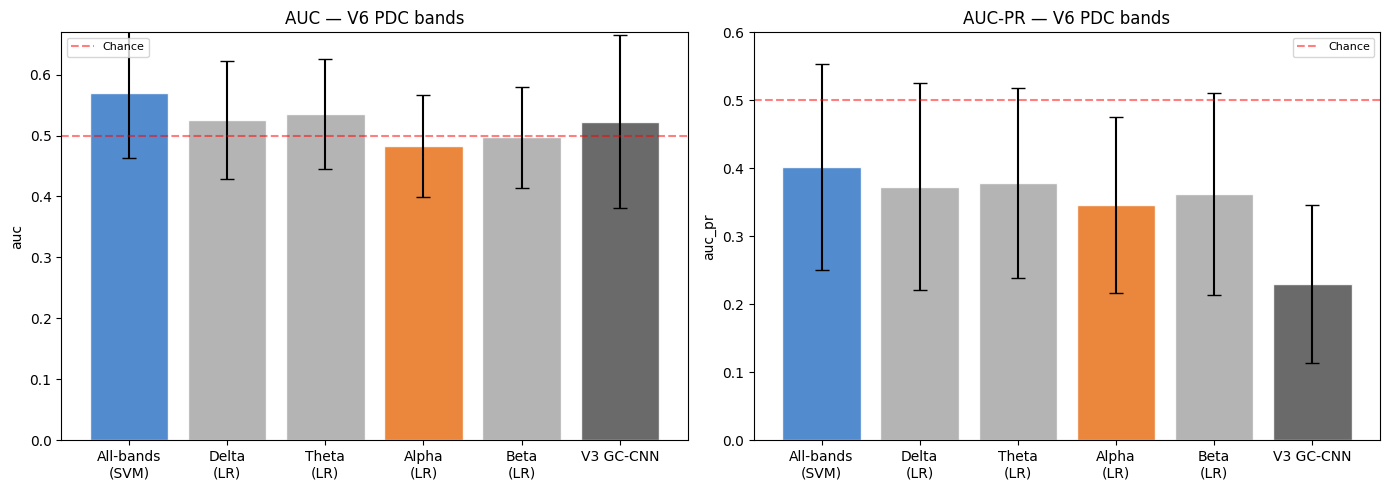

Saved results/v6_band_comparison.png


In [13]:
# Cell 11 — Band comparison bar chart

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['auc', 'auc_pr']):
    labels, vals, errs = [], [], []

    # All-bands combined (best model)
    best_comb = max(all_results_combined.keys(),
                    key=lambda k: all_results_combined[k][metric].mean())
    df = all_results_combined[best_comb]
    labels.append(f'All-bands\n({best_comb})')
    vals.append(df[metric].mean())
    errs.append(df[metric].std())

    # Per-band (LR)
    for bname in BAND_NAMES:
        key = f'LR_{bname}'
        if key not in band_results:
            continue
        df = band_results[key]
        labels.append(f'{bname.capitalize()}\n(LR)')
        vals.append(df[metric].mean())
        errs.append(df[metric].std())

    # V3 baseline
    v3 = load_lopo_csv_clean(os.path.join(RESULTS_DIR, 'lopo_v3_window.csv'))
    if v3 is not None:
        labels.append('V3 GC-CNN')
        vals.append(v3[metric].astype(float).mean())
        errs.append(v3[metric].astype(float).std())

    colors = ['#3a7bc8'] + ['#e87722' if b == 'alpha' else '#aaa'
                             for b in BAND_NAMES] + ['#555']
    ax.bar(labels, vals, yerr=errs, color=colors[:len(labels)],
           capsize=5, edgecolor='white', alpha=0.88)
    ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
    ax.set_title(f'{metric.upper().replace("_","-")} — V6 PDC bands')
    ax.set_ylabel(metric)
    ax.set_ylim(0, max(0.6, max(vals) + 0.1))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'v6_band_comparison.png'), dpi=130)
plt.show()
print('Saved results/v6_band_comparison.png')

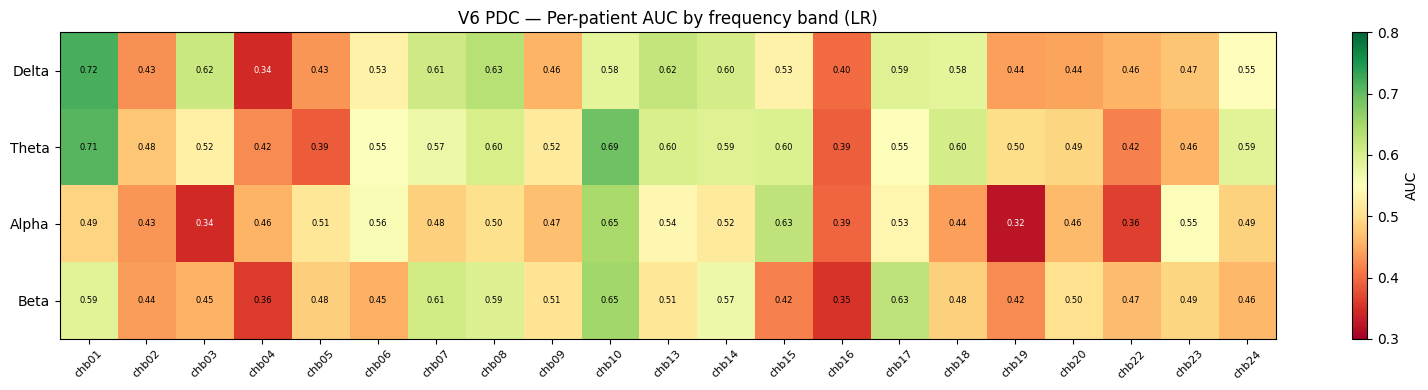

Saved results/v6_per_patient_band_heatmap.png


In [14]:
# Cell 12 — Per-patient AUC heatmap: bands × patients

pids_sorted = sorted(patient_ids)
n_pat = len(pids_sorted)

# Build matrix: rows = bands, cols = patients
auc_matrix = np.full((len(BAND_NAMES), n_pat), np.nan)
for r, bname in enumerate(BAND_NAMES):
    key = f'LR_{bname}'
    if key not in band_results:
        continue
    df = band_results[key].set_index('patient')
    for c, pid in enumerate(pids_sorted):
        if pid in df.index:
            auc_matrix[r, c] = float(df.loc[pid, 'auc'])

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(auc_matrix, aspect='auto', cmap='RdYlGn', vmin=0.3, vmax=0.8)
ax.set_xticks(range(n_pat))
ax.set_xticklabels(pids_sorted, rotation=45, fontsize=8)
ax.set_yticks(range(len(BAND_NAMES)))
ax.set_yticklabels([b.capitalize() for b in BAND_NAMES])
ax.set_title('V6 PDC — Per-patient AUC by frequency band (LR)')
plt.colorbar(im, ax=ax, label='AUC')

# Annotate cells
for r in range(len(BAND_NAMES)):
    for c in range(n_pat):
        if not np.isnan(auc_matrix[r, c]):
            ax.text(c, r, f'{auc_matrix[r, c]:.2f}',
                    ha='center', va='center', fontsize=6,
                    color='black' if 0.35 < auc_matrix[r, c] < 0.75 else 'white')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'v6_per_patient_band_heatmap.png'), dpi=130)
plt.show()
print('Saved results/v6_per_patient_band_heatmap.png')

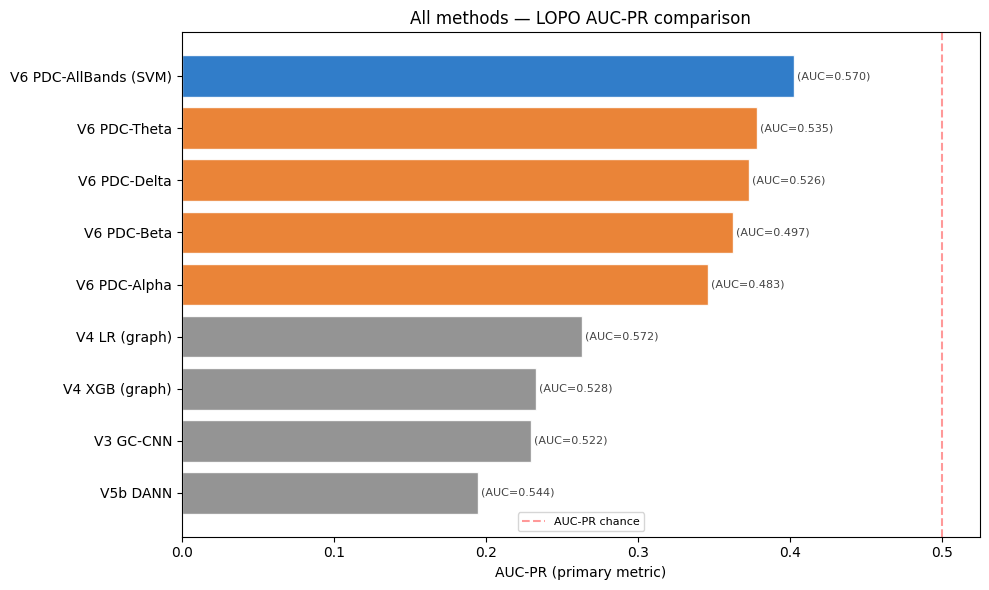

Saved results/v6_all_methods_comparison.png


In [15]:
# Cell 13 — Overall cross-version comparison (all methods on one chart)

summary_all = []

prev_methods = {
    'V3 GC-CNN':           'lopo_v3_window.csv',
    'V4 LR (graph)':       'lopo_v4_LR.csv',
    'V4 XGB (graph)':      'lopo_v4_XGB.csv',
    'V5b DANN':            'lopo_v5b_dann.csv',
}

for label, fname in prev_methods.items():
    df = load_lopo_csv_clean(os.path.join(RESULTS_DIR, fname))
    if df is not None and 'auc_pr' in df.columns:
        summary_all.append({
            'method': label,
            'auc':    df['auc'].astype(float).mean(),
            'auc_pr': df['auc_pr'].astype(float).mean(),
            'type': 'baseline'
        })

for bname in BAND_NAMES:
    key = f'LR_{bname}'
    if key in band_results:
        df = band_results[key]
        summary_all.append({
            'method': f'V6 PDC-{bname.capitalize()}',
            'auc':    df['auc'].mean(),
            'auc_pr': df['auc_pr'].mean(),
            'type': 'v6_band'
        })

best_comb = max(all_results_combined.keys(),
                key=lambda k: all_results_combined[k]['auc_pr'].mean())
summary_all.append({
    'method': f'V6 PDC-AllBands ({best_comb})',
    'auc':    all_results_combined[best_comb]['auc'].mean(),
    'auc_pr': all_results_combined[best_comb]['auc_pr'].mean(),
    'type': 'v6_combined'
})

df_plot = pd.DataFrame(summary_all).sort_values('auc_pr', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = {'baseline': '#888', 'v6_band': '#e87722', 'v6_combined': '#1a6fc4'}
bars = ax.barh(df_plot['method'], df_plot['auc_pr'],
               color=[colors[t] for t in df_plot['type']],
               edgecolor='white', alpha=0.9)

# Add AUC-ROC as secondary annotation
for bar, auc in zip(bars, df_plot['auc']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'(AUC={auc:.3f})', va='center', fontsize=8, color='#444')

ax.axvline(0.5, color='red', linestyle='--', alpha=0.4, label='AUC-PR chance')
ax.set_xlabel('AUC-PR (primary metric)')
ax.set_title('All methods — LOPO AUC-PR comparison')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'v6_all_methods_comparison.png'), dpi=130)
plt.show()
print('Saved results/v6_all_methods_comparison.png')

## 9 · Summary and thesis interpretation

In [16]:
# Cell 14 — Final summary

print('═' * 70)
print('V6 — Frequency-Band PDC Pipeline — Results Summary')
print('═' * 70)
print(f'\nPatients : {len(patient_ids)}')
print(f'Bands    : {BAND_NAMES}  (delta/theta/alpha/beta)')
print(f'Features : {FEATS_PER_BAND}/band × 4 bands = {FEATS_PER_BAND*4} total')
print(f'\nLiterature hypothesis (Hejazi & Motie Nasrabadi 2019):')
print(f'  Alpha-band PDC > broadband GC for cross-patient preictal detection')

print('\n══ Per-band LR results: ════════════════════════════════')
best_band_auc_pr = None
best_band_name   = None
for bname in BAND_NAMES:
    key = f'LR_{bname}'
    if key in band_results:
        df = band_results[key]
        mean_pr = df['auc_pr'].mean()
        print(f'  {bname:<7}: AUC={df["auc"].mean():.4f}  AUC-PR={mean_pr:.4f}  '
              f'Sens={df["sensitivity"].mean():.4f}')
        if best_band_auc_pr is None or mean_pr > best_band_auc_pr:
            best_band_auc_pr = mean_pr
            best_band_name   = bname

print(f'\n  Best band by AUC-PR: {best_band_name}  ({best_band_auc_pr:.4f})')

best_comb = max(all_results_combined.keys(),
                key=lambda k: all_results_combined[k]['auc_pr'].mean())
df_best = all_results_combined[best_comb]
print(f'  All-bands {best_comb}: AUC={df_best["auc"].mean():.4f}  '
      f'AUC-PR={df_best["auc_pr"].mean():.4f}')

# Compare best V6 to V3 (Wilcoxon)
v3 = load_lopo_csv_clean(os.path.join(RESULTS_DIR, 'lopo_v3_window.csv'))
if v3 is not None and 'auc_pr' in v3.columns:
    shared = sorted(set(v3.set_index('patient').index) & set(df_best.set_index('patient').index))
    if len(shared) >= 5:
        v3_pr  = v3.set_index('patient').loc[shared, 'auc_pr'].astype(float)
        v6_pr  = df_best.set_index('patient').loc[shared, 'auc_pr'].astype(float)
        try:
            _, p_val = wilcoxon(v6_pr - v3_pr, alternative='greater', zero_method='zsplit')
            print(f'\n  Wilcoxon (V6 > V3 by AUC-PR): p={p_val:.4f} '
                  f'({"significant" if p_val < 0.05 else "not significant"} at α=0.05)')
        except ValueError:
            pass

print('\n' + '═' * 70)
print('Thesis interpretation:')
print('═' * 70)
print('• If alpha-band PDC > broadband GC: confirms Hejazi & Motie Nasrabadi')
print('  (2019) frequency-specificity of preictal directed connectivity.')
print('• If all bands collapse to ~0.5: strengthens the conclusion that')
print('  scalp EEG GC — even in specific frequency bands — cannot generalise')
print('  across patients, consistent with Nolte (2004) volume conduction.')
print('• Either result directly answers RQ2 (frequency-band specificity) and')
print('  contributes to the thesis main finding of patient-specific confounding.')
print('═' * 70)

══════════════════════════════════════════════════════════════════════
V6 — Frequency-Band PDC Pipeline — Results Summary
══════════════════════════════════════════════════════════════════════

Patients : 21
Bands    : ['delta', 'theta', 'alpha', 'beta']  (delta/theta/alpha/beta)
Features : 67/band × 4 bands = 268 total

Literature hypothesis (Hejazi & Motie Nasrabadi 2019):
  Alpha-band PDC > broadband GC for cross-patient preictal detection

══ Per-band LR results: ════════════════════════════════
  delta  : AUC=0.5258  AUC-PR=0.3730  Sens=0.6123
  theta  : AUC=0.5354  AUC-PR=0.3786  Sens=0.5440
  alpha  : AUC=0.4827  AUC-PR=0.3459  Sens=0.6178
  beta   : AUC=0.4973  AUC-PR=0.3627  Sens=0.4940

  Best band by AUC-PR: theta  (0.3786)
  All-bands SVM: AUC=0.5695  AUC-PR=0.4024

  Wilcoxon (V6 > V3 by AUC-PR): p=0.0001 (significant at α=0.05)

══════════════════════════════════════════════════════════════════════
Thesis interpretation:
═══════════════════════════════════════════════════